# Convolutional Autoencoder with Deconvolutions

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

2025-09-29 11:51:27.317543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759146687.517903      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759146687.571101      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Dataset

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and reshape for your model
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# If your graph expects flat vectors (784)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


## Settings

In [3]:
# Hyperparameters
learning_rate = 0.001
training_epochs = 5
batch_size = 128

# Architecture
hidden_size = 16
input_size = 784
image_width = 28

# Other
print_interval = 200
random_seed = 123

## GRAPH DEFINITION

In [4]:
pip install tensorflow==2.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.2/524.2 MB 3.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 87.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 85.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.8/440.8 kB 25.0 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.14.0
    Uninstalling typing_extensions-4.14.0:
      Successfully uninstalled typing_extensions-4.14.0
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0
  Attempting uninstall: gast
    Found existing installation: gast 0.6.0
    Uni

In [13]:
g = tf.Graph()
with g.as_default():
    
    tf.compat.v1.set_random_seed(random_seed) 

    # Input data
    tf_x = tf.compat.v1.placeholder(tf.float32, [None, input_size], name='inputs')
    input_layer = tf.reshape(tf_x, shape=[-1, image_width, image_width, 1])

    # Encoder
    
    # 28x28x1 => 28x28x8
    conv1 = tf.keras.layers.Conv2D(filters=8, kernel_size=(3, 3),
                             strides=(1, 1), padding='same', 
                             activation='relu')(input_layer)
    # 28x28x8 => 14x14x8
    maxpool1 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), 
                                       strides=(2, 2), padding='same')(conv1)
    
    # 14x14x8 => 14x14x4
    conv2 = tf.keras.layers.Conv2D(filters=4, kernel_size=(3, 3), 
                             strides=(1, 1), padding='same', 
                             activation='relu')(maxpool1)
    
    # 14x14x4 => 7x7x4
    encode = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), 
                                     strides=(2, 2), padding='same', 
                                     name='encoding')(conv2)

    # Decoder
    
    # 7x7x4 => 14x14x8
    deconv1 = tf.keras.layers.Conv2DTranspose(filters=8, 
                                         kernel_size=(3, 3), strides=(2, 2), 
                                         padding='same',
                                         activation='relu')(encode)
    
    
    # 14x14x8 => 28x28x8
    deconv2 = tf.keras.layers.Conv2DTranspose(filters=8, 
                                         kernel_size=(3, 3), strides=(2, 2), 
                                         padding='same',
                                         activation='relu')(deconv1)
    
    # 28x28x8 => 28x28x1
    logits = tf.keras.layers.Conv2D(filters=1, kernel_size=(3,3), 
                              strides=(1, 1), padding='same', 
                              activation=None)(deconv2)
    
    decode = tf.nn.sigmoid(logits, name='decoding')

    # Loss & Optimizer
    
    loss = tf.nn.sigmoid_cross_entropy_with_logits(labels=input_layer,
                                                   logits=logits)
    cost = tf.reduce_mean(loss, name='cost')
    optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate)
    train = optimizer.minimize(cost, name='train')    

    # Saver to save session for reuse
    saver = tf.compat.v1.train.Saver()

## TRAINING & EVALUATION

In [19]:
import numpy as np
import tensorflow as tf

tf.compat.v1.disable_eager_execution()   # important!

with tf.compat.v1.Session(graph=g) as sess:
    sess.run(tf.compat.v1.global_variables_initializer())

    np.random.seed(random_seed)
    num_examples = x_train.shape[0]

    np.random.seed(random_seed) # random seed for mnist iterator
    for epoch in range(training_epochs):
        avg_cost = 0.
        total_batch = num_examples // batch_size

        indices = np.arange(num_examples)
        np.random.shuffle(indices)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train[indices]

        for i in range(total_batch):
            start = i * batch_size
            end = start + batch_size
            batch_x = x_train_shuffled[start:end].reshape(-1, 784)  # flatten
            batch_y = y_train_shuffled[start:end]
            _, c = sess.run(['train', 'cost:0'], feed_dict={'inputs:0': batch_x})

            avg_cost += c

            if not i % print_interval:
                print("Minibatch: %03d | Cost:    %.3f" % (i + 1, c))

        print("Epoch:     %03d | AvgCost: %.3f" % (epoch + 1, avg_cost / (i + 1)))
    
    saver.save(sess, save_path='./autoencoder.ckpt')

I0000 00:00:1759147394.214107      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1759147394.434551     134 cuda_dnn.cc:529] Loaded cuDNN version 90300


Minibatch: 001 | Cost:    0.692
Minibatch: 201 | Cost:    0.166
Minibatch: 401 | Cost:    0.104
Epoch:     001 | AvgCost: 0.223
Minibatch: 001 | Cost:    0.102
Minibatch: 201 | Cost:    0.094
Minibatch: 401 | Cost:    0.089
Epoch:     002 | AvgCost: 0.094
Minibatch: 001 | Cost:    0.088
Minibatch: 201 | Cost:    0.085
Minibatch: 401 | Cost:    0.086
Epoch:     003 | AvgCost: 0.088
Minibatch: 001 | Cost:    0.084
Minibatch: 201 | Cost:    0.085
Minibatch: 401 | Cost:    0.086
Epoch:     004 | AvgCost: 0.085
Minibatch: 001 | Cost:    0.081
Minibatch: 201 | Cost:    0.088
Minibatch: 401 | Cost:    0.085
Epoch:     005 | AvgCost: 0.084


## VISUALIZATION

I0000 00:00:1759147449.745911      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


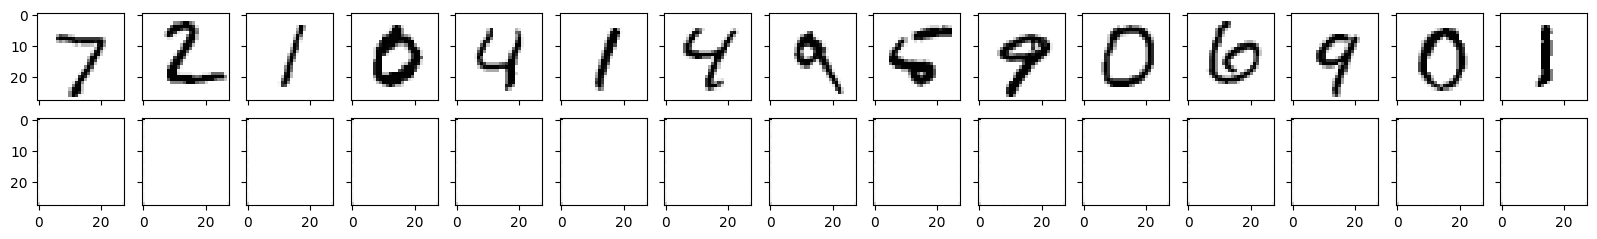

In [23]:
import matplotlib.pyplot as plt

n_images = 15

fig, axes = plt.subplots(nrows=2, ncols=n_images, sharex=True, 
                         sharey=True, figsize=(20, 2.5))
test_images = x_test[:n_images].reshape(-1, 784) / 255.0

with tf.compat.v1.Session(graph=g) as sess:
    saver.restore(sess, save_path='./autoencoder.ckpt')
    decoded = sess.run('decoding:0', feed_dict={'inputs:0': test_images})

for i in range(n_images):
    for ax, img in zip(axes, [test_images, decoded]):
        ax[i].imshow(img[i].reshape((image_width, image_width)), cmap='binary')